# Chocolate sales — exploratory data analysis

Imports, dataset download, data-quality checks (sales/products/stores/customers only), merged transaction table, univariate plots, correlation matrix (Pearson + Spearman), scatter plots for pairs with **|r| > 0.7**, and time/categorical views from `sales.order_date` (no `calendar.csv`).

In [17]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

sns.set_theme(style="whitegrid")

# Download latest version
path = kagglehub.dataset_download("ssssws/chocolate-sales-dataset-2023-2024")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Yonatan\.cache\kagglehub\datasets\ssssws\chocolate-sales-dataset-2023-2024\versions\2


## Load CSV files

All tables live under the path returned by `kagglehub`.

In [18]:
DATA_DIR = Path(path)
stems = ("sales", "products", "stores", "customers")
files = {s: DATA_DIR / f"{s}.csv" for s in stems}

sales = pd.read_csv(files["sales"])
products = pd.read_csv(files["products"])
stores = pd.read_csv(files["stores"])
customers = pd.read_csv(files["customers"])

tables = {"sales": sales, "products": products, "stores": stores, "customers": customers}


## 0. Data quality (before main EDA)

Per-table: shape, duplicate rows, missing values, dtypes, and quick validity rules where applicable.

In [19]:
def report_quality(name: str, df: pd.DataFrame) -> None:
    print(f"=== {name} ===")
    print(f"shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
    dup = df.duplicated().sum()
    print(f"duplicate rows: {dup:,}")
    na = df.isna()
    total_na = int(na.sum().sum())
    if total_na == 0:
        print("missing values: none")
    else:
        print("missing values (count / %):")
        miss = na.mean() * 100
        print(miss[miss > 0].sort_values(ascending=False).to_string())
    print("dtypes:\n", df.dtypes.to_string())
    print()


for label, frame in tables.items():
    report_quality(label, frame)

# Transaction-level sanity checks on sales
s = sales
valid_qty = (s["quantity"] >= 0).all()
valid_money = (s[["unit_price", "revenue", "cost", "profit"]] >= 0).all().all()
disc = (s["discount"] >= 0) & (s["discount"] <= 1)
print("sales validity: quantity >= 0:", valid_qty)
print("sales validity: money cols >= 0:", valid_money)
print("sales validity: discount in [0, 1]:", bool(disc.all()))

=== sales ===
shape: 1,000,000 rows × 11 cols
duplicate rows: 0
missing values: none
dtypes:
 order_id        object
order_date      object
product_id      object
store_id        object
customer_id     object
quantity         int64
unit_price     float64
discount       float64
revenue        float64
cost           float64
profit         float64

=== products ===
shape: 200 rows × 6 cols
duplicate rows: 0
missing values: none
dtypes:
 product_id       object
product_name     object
brand            object
category         object
cocoa_percent     int64
weight_g          int64

=== stores ===
shape: 100 rows × 5 cols
duplicate rows: 0
missing values: none
dtypes:
 store_id      object
store_name    object
city          object
country       object
store_type    object

=== customers ===
shape: 50,000 rows × 5 cols
duplicate rows: 0
missing values: none
dtypes:
 customer_id       object
age                int64
gender            object
loyalty_member     int64
join_date         object

sal

## Merge transactions with dimensions

Inner joins on `product_id`, `store_id`, and `customer_id`. Rows whose `product_id` is missing from `products` are dropped (documented below). `order_date` is parsed from `sales` only for time plots; `calendar.csv` is not used.

In [20]:
n_sales = len(sales)
orph_product = ~sales["product_id"].isin(products["product_id"])
orph_store = ~sales["store_id"].isin(stores["store_id"])
orph_customer = ~sales["customer_id"].isin(customers["customer_id"])
print("orphan product_id rows:", int(orph_product.sum()))
print("orphan store_id rows:", int(orph_store.sum()))
print("orphan customer_id rows:", int(orph_customer.sum()))

df = (
    sales.merge(products, on="product_id", how="inner")
    .merge(stores, on="store_id", how="inner")
    .merge(customers, on="customer_id", how="inner")
)
print(f"\nmerged rows: {len(df):,} (dropped {n_sales - len(df):,} rows without product metadata)")

df["order_date"] = pd.to_datetime(df["order_date"])

dup_merged = df.duplicated().sum()
na_merged = df.isna().sum().sum()
print(f"merged duplicate rows: {dup_merged}")
print(f"merged total NaN cells: {na_merged}")

df.head()

orphan product_id rows: 9764
orphan store_id rows: 0
orphan customer_id rows: 0

merged rows: 990,236 (dropped 9,764 rows without product metadata)
merged duplicate rows: 0
merged total NaN cells: 0


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,70,200,Chocolate Store 93,Sydney,UK,Airport,44,Male,1,2021-11-17
1,0RD00372820,2023-07-11,P0117,S042,C040749,1,12.17,0.00,12.17,7.74,...,50,50,Chocolate Store 42,Paris,USA,Online,44,Male,1,2021-11-17
2,0RD00151766,2024-03-11,P0137,S062,C040749,5,13.19,0.00,65.95,39.50,...,80,100,Chocolate Store 62,Toronto,Canada,Airport,44,Male,1,2021-11-17
3,0RD00541095,2023-07-11,P0110,S017,C040749,3,14.75,0.00,44.25,29.73,...,50,80,Chocolate Store 17,Melbourne,UK,Airport,44,Male,1,2021-11-17
4,0RD00319312,2024-04-03,P0052,S055,C040749,4,3.59,0.00,14.36,8.82,...,90,100,Chocolate Store 55,New York,France,Retail,44,Male,1,2021-11-17


## Profile (`info`, `describe`)

Use this snapshot before plotting and correlations.

In [21]:
df.info()

df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990236 entries, 0 to 990235
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        990236 non-null  object        
 1   order_date      990236 non-null  datetime64[ns]
 2   product_id      990236 non-null  object        
 3   store_id        990236 non-null  object        
 4   customer_id     990236 non-null  object        
 5   quantity        990236 non-null  int64         
 6   unit_price      990236 non-null  float64       
 7   discount        990236 non-null  float64       
 8   revenue         990236 non-null  float64       
 9   cost            990236 non-null  float64       
 10  profit          990236 non-null  float64       
 11  product_name    990236 non-null  object        
 12  brand           990236 non-null  object        
 13  category        990236 non-null  object        
 14  cocoa_percent   990236 non-null  int

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date
count,990236,990236,990236,990236,990236,990236.000000,990236.000000,990236.000000,990236.000000,990236.000000,...,990236.000000,990236.000000,990236,990236,990236,990236,990236.000000,990236,990236.000000,990236
unique,990236,NaN,200,100,50000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,100,7,6,4,NaN,2,NaN,1827
top,0RD00000001,NaN,P0021,S013,C044952,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Chocolate Store 13,Toronto,Canada,Airport,NaN,Male,NaN,2023-09-06
freq,1,NaN,5141,10107,40,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10107,178375,198160,296204,NaN,499412,NaN,910
mean,NaN,2023-12-31 19:24:53.593043712,NaN,NaN,NaN,2.999760,9.002360,0.056242,25.487508,15.292310,...,69.148132,107.431400,NaN,NaN,NaN,NaN,44.044334,NaN,0.501855,NaN
min,NaN,2023-01-01 00:00:00,NaN,NaN,NaN,1.000000,3.000000,0.000000,2.400000,1.200000,...,50.000000,50.000000,NaN,NaN,NaN,NaN,18.000000,NaN,0.000000,NaN
25%,NaN,2023-07-02 00:00:00,NaN,NaN,NaN,2.000000,6.000000,0.000000,12.160000,7.240000,...,50.000000,80.000000,NaN,NaN,NaN,NaN,31.000000,NaN,0.000000,NaN
50%,NaN,2024-01-01 00:00:00,NaN,NaN,NaN,3.000000,9.000000,0.000000,21.920000,13.030000,...,70.000000,100.000000,NaN,NaN,NaN,NaN,44.000000,NaN,1.000000,NaN
75%,NaN,2024-07-02 00:00:00,NaN,NaN,NaN,4.000000,12.000000,0.150000,35.880000,21.420000,...,80.000000,120.000000,NaN,NaN,NaN,NaN,57.000000,NaN,1.000000,NaN
max,NaN,2024-12-31 00:00:00,NaN,NaN,NaN,5.000000,15.000000,0.200000,75.000000,52.430000,...,90.000000,200.000000,NaN,NaN,NaN,NaN,70.000000,NaN,1.000000,NaN


## Univariate EDA

Histograms / KDE for key numeric columns and bar charts for categorical frequency (full data where feasible; a capped random sample for dense seaborn plots).

Numeric columns: ['quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'cocoa_percent', 'weight_g', 'age', 'loyalty_member']


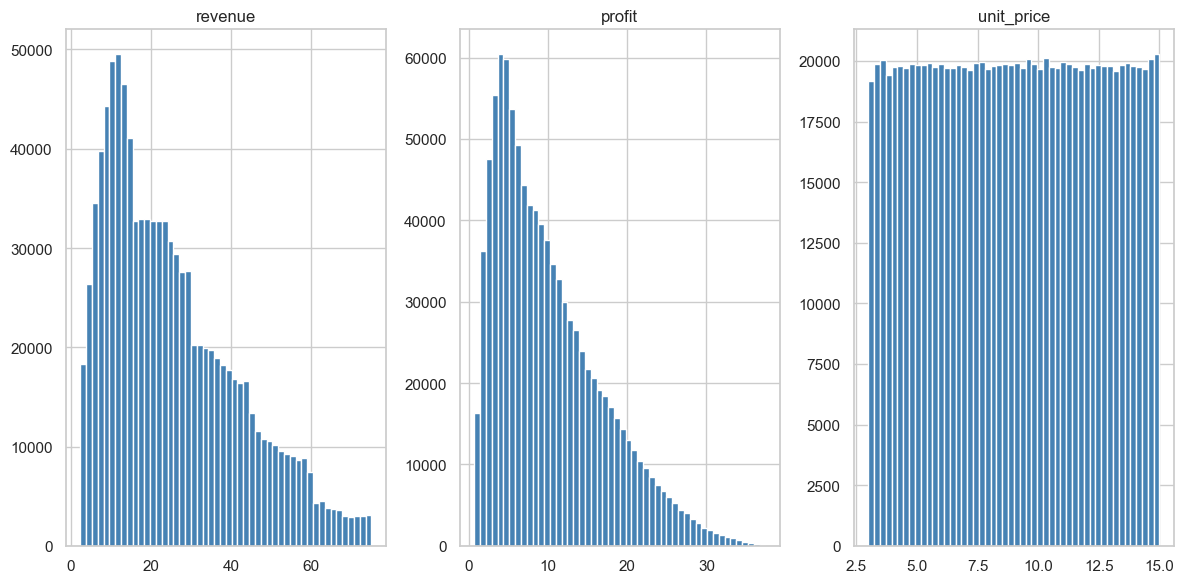

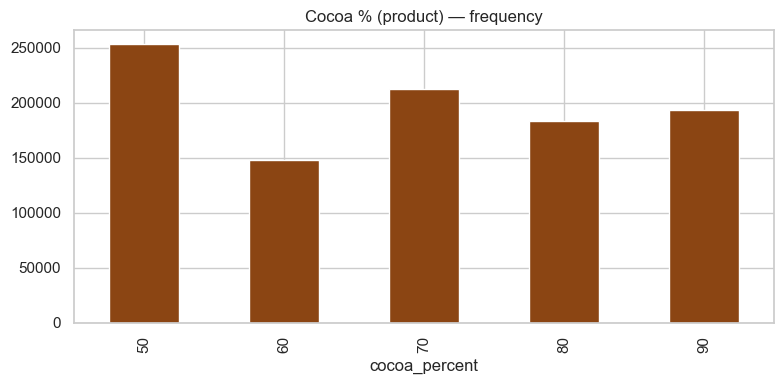

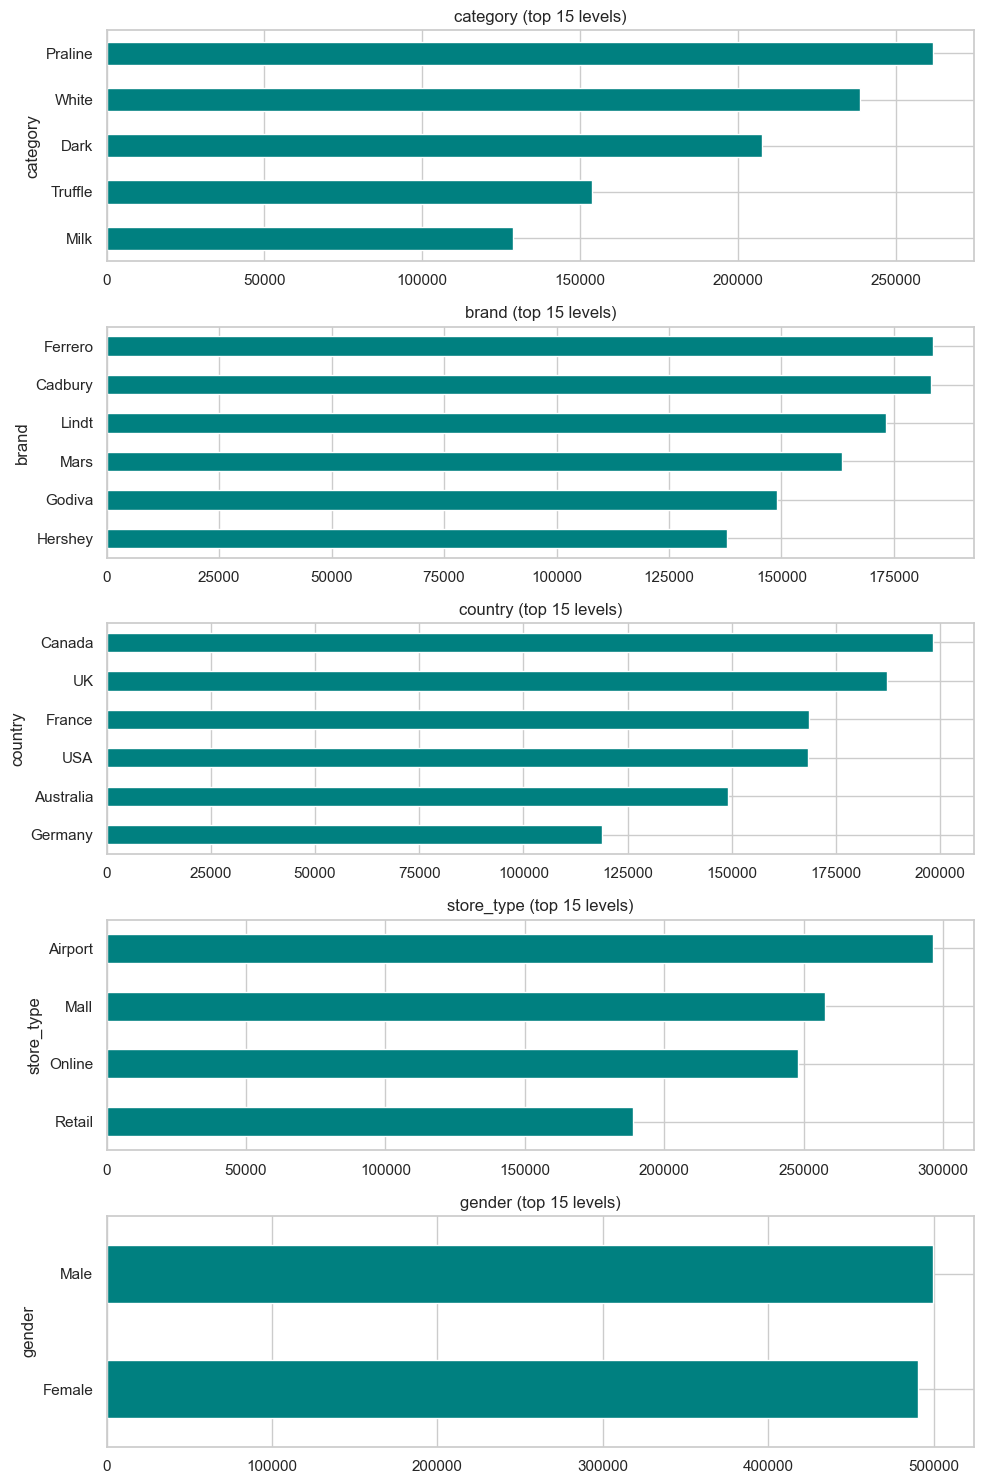

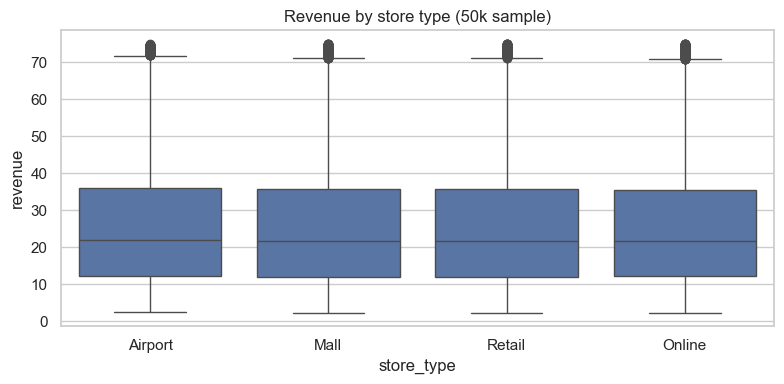

In [22]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Numeric columns:", numeric_cols)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes = axes.ravel()
for ax, col in zip(axes, ["revenue", "profit", "unit_price"]): # abit not relevant:"quantity"
    df[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
df["cocoa_percent"].value_counts().sort_index().plot(kind="bar", ax=ax, color="saddlebrown")
ax.set_title("Cocoa % (product) — frequency")
plt.tight_layout()
plt.show()

cat_cols = ["category", "brand", "country", "store_type", "gender"]
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 3 * len(cat_cols)))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts().head(15)
    vc.sort_values().plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"{col} (top 15 levels)")
plt.tight_layout()
plt.show()

sample_plot = df.sample(n=min(50_000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=sample_plot, x="store_type", y="revenue", ax=ax)
ax.set_title("Revenue by store type (50k sample)")
plt.tight_layout()
plt.show()

## Correlation matrices (numeric features only)

Pearson (linear) and Spearman (monotonic/ordinal-safe). ID-like numeric columns are excluded. Heatmap + sorted pairwise list (upper triangle skipped).

Top 20 Pearson pairs by |r|:
             a              b         r    abs_r
      revenue           cost  0.984524 0.984524
      revenue         profit  0.966194 0.966194
         cost         profit  0.906058 0.906058
     quantity        revenue  0.733963 0.733963
     quantity           cost  0.722682 0.722682
     quantity         profit  0.709035 0.709035
   unit_price        revenue  0.599265 0.599265
   unit_price           cost  0.590006 0.590006
   unit_price         profit  0.578984 0.578984
     discount        revenue -0.127325 0.127325
     discount           cost -0.125151 0.125151
     discount         profit -0.123319 0.123319
cocoa_percent       weight_g  0.004114 0.004114
   unit_price loyalty_member -0.002381 0.002381
       profit loyalty_member -0.002280 0.002280
      revenue loyalty_member -0.002234 0.002234
         cost loyalty_member -0.002118 0.002118
     quantity       weight_g -0.001952 0.001952
         cost  cocoa_percent -0.001926 0.001926
      reve

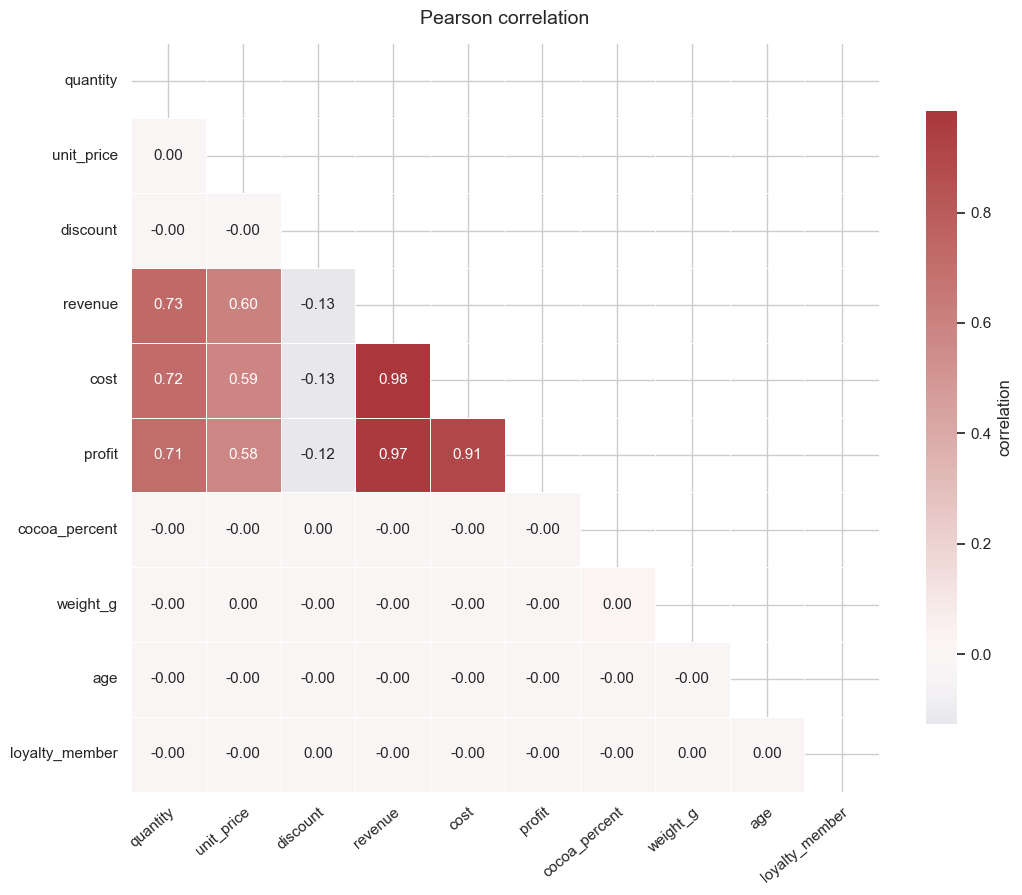

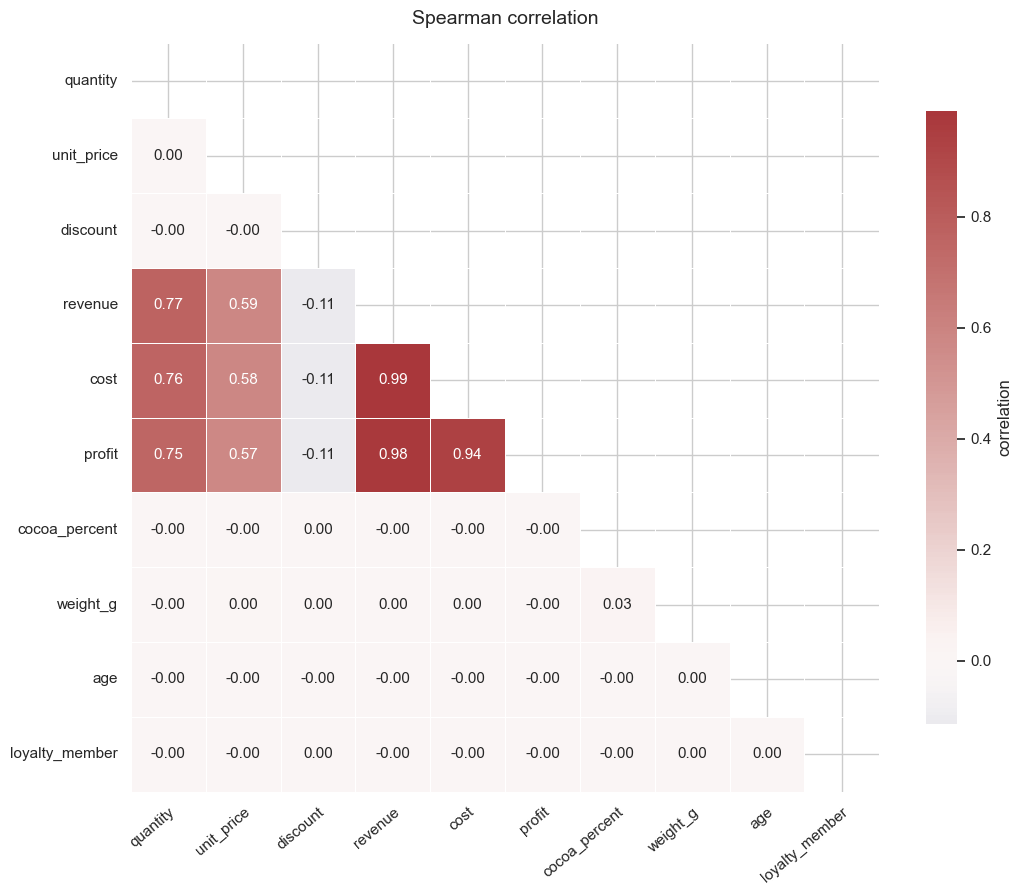

In [26]:
num_df = df.select_dtypes(include="number")
pearson_corr = num_df.corr(method="pearson")
spearman_corr = num_df.corr(method="spearman")


def corr_pairs_long(corr: pd.DataFrame):
    cols = corr.columns
    rows = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr.iloc[i, j]
            rows.append((cols[i], cols[j], r))
    return pd.DataFrame(rows, columns=["a", "b", "r"]).assign(abs_r=lambda d: d["r"].abs())


pair_pearson = corr_pairs_long(pearson_corr).sort_values("abs_r", ascending=False)
pair_spearman = corr_pairs_long(spearman_corr).sort_values("abs_r", ascending=False)

print("Top 20 Pearson pairs by |r|:\n", pair_pearson.head(20).to_string(index=False))
print("\nTop 20 Spearman pairs by |r|:\n", pair_spearman.head(20).to_string(index=False))

mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
heat_kw = dict(
    mask=mask,
    cmap="vlag",
    center=0,
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11, "ha": "center", "va": "center"},
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.82, "label": "correlation"},
)

for corr_mat, title in ((pearson_corr, "Pearson correlation"), (spearman_corr, "Spearman correlation")):
    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(corr_mat, ax=ax, **heat_kw)
    ax.set_title(title, fontsize=14, pad=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    plt.show()





## Strong correlations: **|r| > 0.7** (Pearson)

Scatter + regression line on a random sample (full data has ~1M points per panel). Pairs are taken from the Pearson pairwise table; inspect the Spearman table above for monotonic but nonlinear links.

Pairs with |r| > 0.7 (Pearson): 6
       a       b        r    abs_r
 revenue    cost 0.984524 0.984524
 revenue  profit 0.966194 0.966194
    cost  profit 0.906058 0.906058
quantity revenue 0.733963 0.733963
quantity    cost 0.722682 0.722682
quantity  profit 0.709035 0.709035


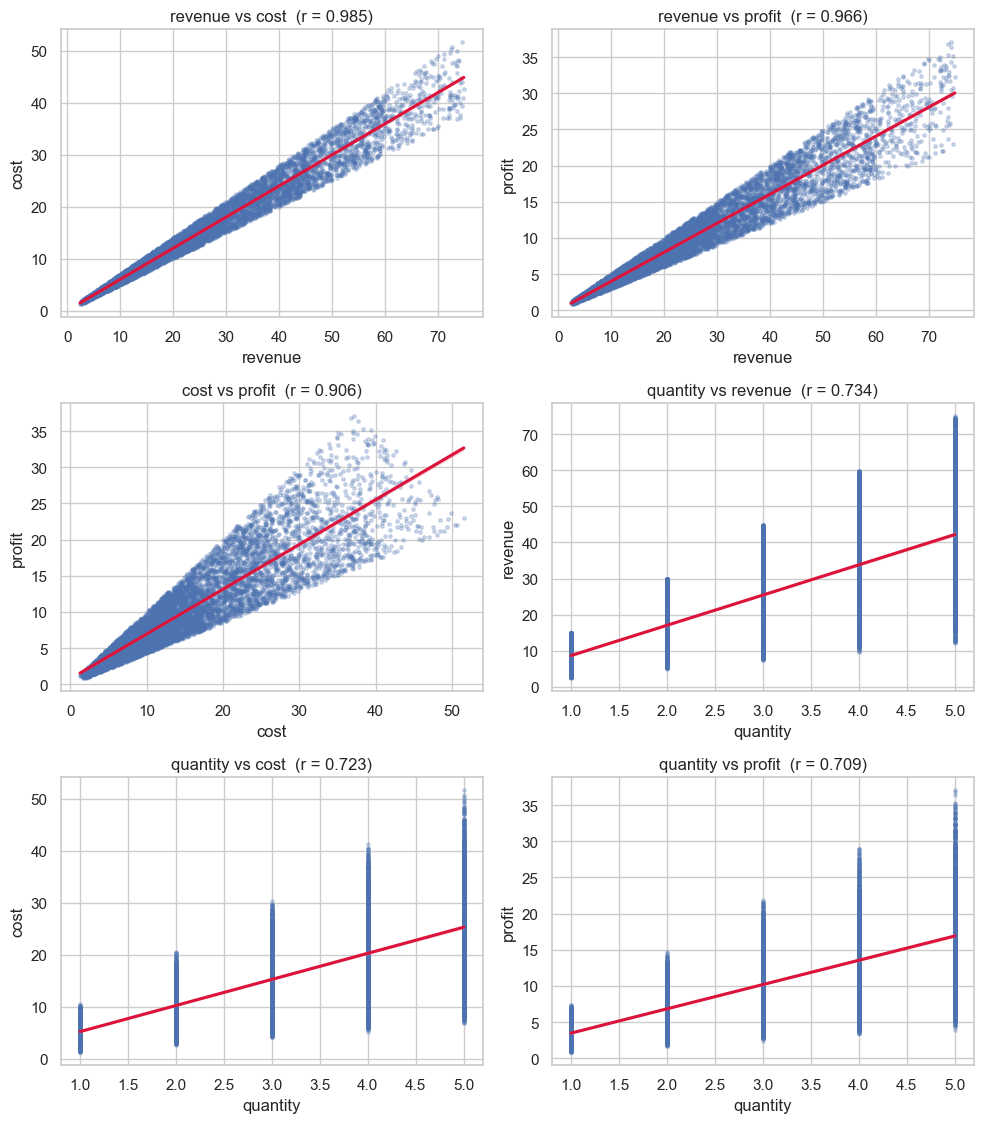

In [24]:
THRESH = 0.7
strong_pairs = pair_pearson[pair_pearson["abs_r"] > THRESH].copy()
print(f"Pairs with |r| > {THRESH} (Pearson): {len(strong_pairs)}")
print(strong_pairs.to_string(index=False))

plot_sample = df.sample(n=min(8_000, len(df)), random_state=42)

if strong_pairs.empty:
    print("No variable pairs exceed the threshold; try lowering THRESH or using Spearman pairs.")
else:
    n = len(strong_pairs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, row in zip(axes, strong_pairs.itertuples(index=False)):
        sns.regplot(
            data=plot_sample,
            x=row.a,
            y=row.b,
            ax=ax,
            scatter_kws={"s": 6, "alpha": 0.25},
            line_kws={"color": "crimson"},
        )
        ax.set_title(f"{row.a} vs {row.b}  (r = {row.r:.3f})")
    for k in range(n, len(axes)):
        axes[k].set_axis_off()
    plt.tight_layout()
    plt.show()

## Time series and categorical bivariate views

**Target for this story:** `revenue` (and `profit`) per line item. Daily aggregates show seasonality; boxplots compare revenue across product `category` and `country` (sampled for rendering).

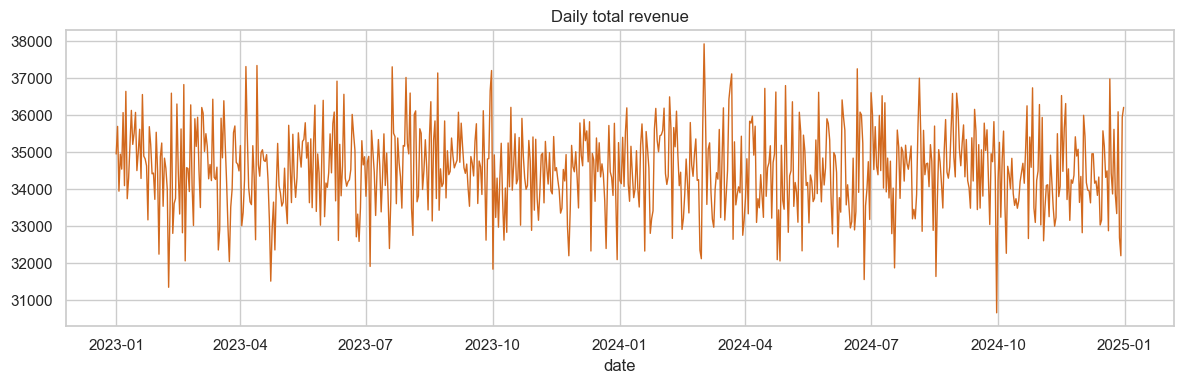

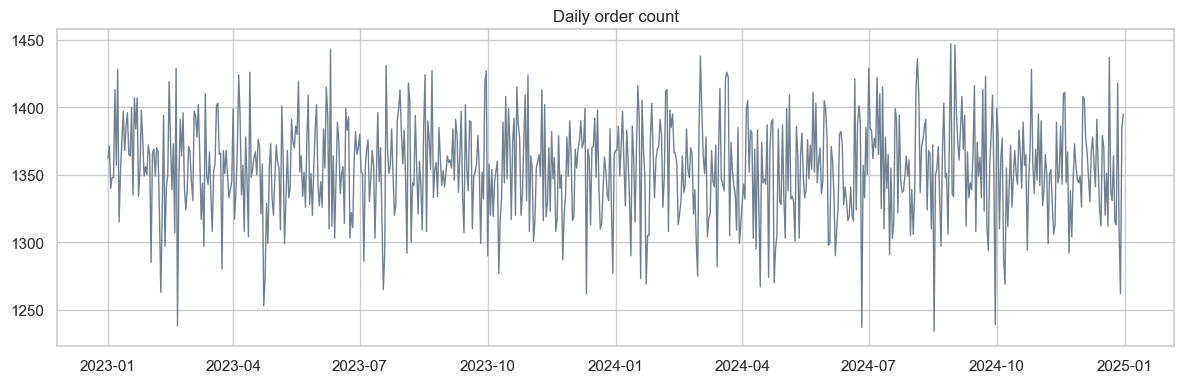

C:\Users\Yonatan\AppData\Local\Temp\ipykernel_7852\785797266.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")


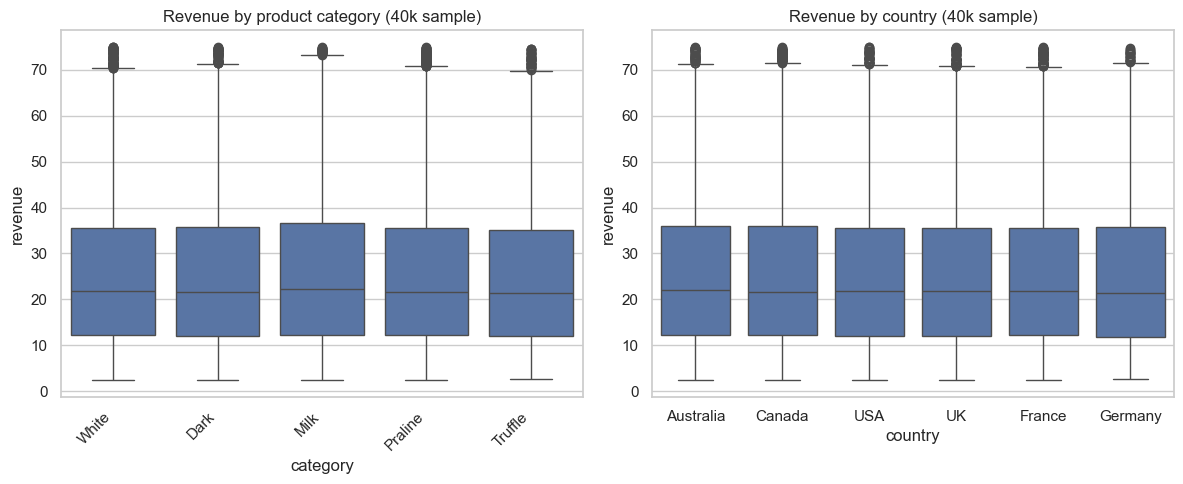

In [25]:
daily = (
    df.groupby("order_date", as_index=False)
    .agg(revenue_sum=("revenue", "sum"), profit_sum=("profit", "sum"), orders=("order_id", "count"))
    .sort_values("order_date")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["order_date"], daily["revenue_sum"], color="chocolate", linewidth=1)
ax.set_title("Daily total revenue")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["order_date"], daily["orders"], color="slategray", linewidth=1)
ax.set_title("Daily order count")
plt.tight_layout()
plt.show()

sample_box = df.sample(n=min(40_000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=sample_box, x="category", y="revenue", ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].set_title("Revenue by product category (40k sample)")

sns.boxplot(data=sample_box, x="country", y="revenue", ax=axes[1])
axes[1].set_title("Revenue by country (40k sample)")
plt.tight_layout()
plt.show()